# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [2]:
# wczytanie zbioru danych
titanic = pd.read_csv("train.csv")

titanic.shape

(891, 12)

In [3]:
# MIEJSCE NA TWÓJ KOD
print(titanic.dtypes)
titanic.info()
display(titanic.describe())
print(titanic.isnull().sum())

opisy = {
    'survival':  ['Binarna',    'Czy pasażer przeżył (0 = No, 1 = Yes)'],
    'pclass':    ['Porządkowa', 'Klasa biletu (1 = 1st, 2 = 2nd, 3 = 3rd)'],
    'sex':       ['Nominalna',  'Płeć pasażera'],
    'age':       ['Ciągła',     'Wiek pasażera w latach'],
    'sibsp':     ['Dyskretna',  'Liczba rodzeństwa/małżonków na pokładzie'],
    'parch':     ['Dyskretna',  'Liczba rodziców/dzieci na pokładzie'],
    'ticket':    ['Nominalna',  'Numer biletu'],
    'fare':      ['Ciągła',     'Cena biletu pasażera'],
    'cabin':     ['Nominalna',  'Numer kabiny'],
    'embarked':  ['Nominalna',  'Port zaokrętowania (C = Cherbourg, Q = Queenstown, S = Southampton)'],
}

opis_df = pd.DataFrame.from_dict(opisy, orient='index', columns=['Typ zmiennej', 'Opis'])
opis_df.index.name = 'Kolumna'
display(opis_df)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,Typ zmiennej,Opis
Kolumna,,
survival,Binarna,"Czy pasażer przeżył (0 = No, 1 = Yes)"
pclass,Porządkowa,"Klasa biletu (1 = 1st, 2 = 2nd, 3 = 3rd)"
sex,Nominalna,Płeć pasażera
age,Ciągła,Wiek pasażera w latach
sibsp,Dyskretna,Liczba rodzeństwa/małżonków na pokładzie
parch,Dyskretna,Liczba rodziców/dzieci na pokładzie
ticket,Nominalna,Numer biletu
fare,Ciągła,Cena biletu pasażera
cabin,Nominalna,Numer kabiny


## Przekształcenie danych

In [4]:
# MIEJSCE NA TWÓJ KOD
print(titanic['Age'].describe())
print(titanic[titanic['Age'] > 100])

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

In [5]:
# MIEJSCE NA TWÓJ KOD
titanic["Age"] = titanic["Age"].ffill()
print(titanic['Age'].describe())
print(titanic[titanic['Age'] > 100])

count    891.00000
mean      29.58156
std       14.55459
min        0.42000
25%       20.00000
50%       28.00000
75%       38.00000
max       80.00000
Name: Age, dtype: float64
Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


In [6]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"

### Zaokrętowanie

In [7]:
# MIEJSCE NA TWÓJ KOD
titanic["Embarked"] = titanic["Embarked"].ffill()

In [8]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

In [9]:
# MIEJSCE NA TWÓJ KOD
titanic['Cabin'] = titanic['Cabin'].str[0]
titanic['Cabin'] = titanic['Cabin'].fillna('U')

In [10]:
assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [11]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

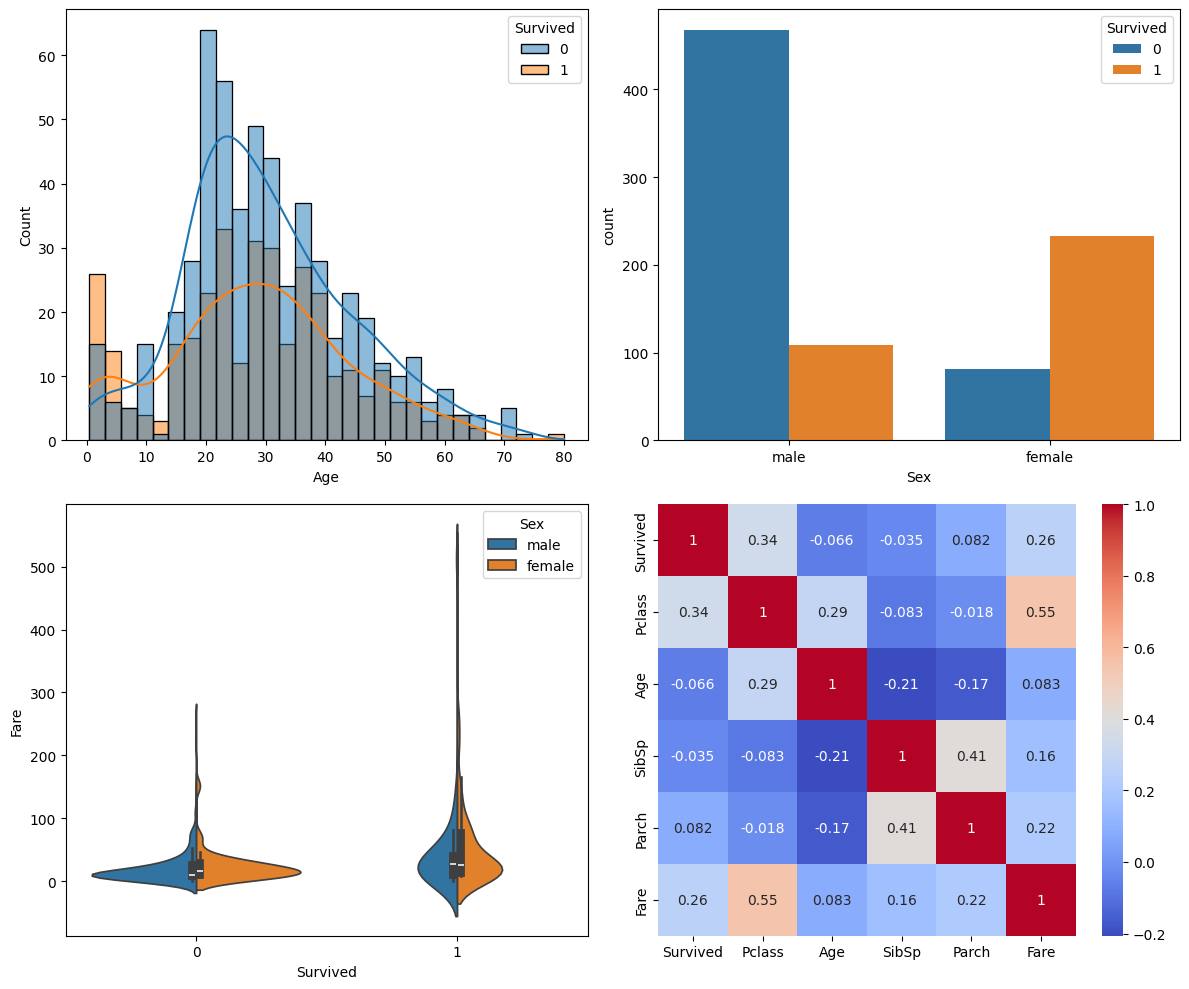

In [12]:
# MIEJSCE NA TWÓJ KOD

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

titanic_corr = titanic.copy()
titanic_corr['Pclass'] = 4 - titanic_corr['Pclass']  # 1→3, 2→2, 3→1

sns.histplot(data=titanic, x='Age', hue='Survived', kde=True, bins=30, ax=axes[0,0])
sns.countplot(data=titanic, x='Sex', hue='Survived', ax=axes[0,1])
sns.violinplot(data=titanic, x='Survived', y='Fare', hue='Sex', split=True, ax=axes[1,0])
sns.heatmap(titanic_corr.select_dtypes(include='number').drop(columns=["PassengerId"]).corr(), annot=True, cmap='coolwarm', ax=axes[1,1])

plt.tight_layout()
plt.show()

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

In [13]:
# MIEJSCE NA TWÓJ KOD
print(titanic.groupby('Sex')['Survived'].mean().sort_values(ascending=False))
print(titanic.groupby('Pclass')['Survived'].mean().sort_values(ascending=False))
print(titanic.groupby('Embarked')['Survived'].mean().sort_values(ascending=False))

print("---")

survival_rate = titanic.groupby(['Sex', 'Pclass'])['Survived'].mean().reset_index()
survival_rate.columns = ['Sex', 'Pclass', 'Survival Rate']
survival_rate = survival_rate.sort_values('Survival Rate', ascending=False)
print(survival_rate)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Embarked
C    0.556213
Q    0.397436
S    0.336957
Name: Survived, dtype: float64
---
      Sex  Pclass  Survival Rate
0  female       1       0.968085
1  female       2       0.921053
2  female       3       0.500000
3    male       1       0.368852
4    male       2       0.157407
5    male       3       0.135447


# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [38]:
import kagglehub
import os

spotify_ds = kagglehub.dataset_download(
  "maharshipandya/-spotify-tracks-dataset"
)

print(os.listdir(spotify_ds))

spotify = pd.read_csv(os.path.join(spotify_ds, "dataset.csv"))

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
['dataset.csv']


In [39]:
print(spotify.dtypes)
spotify.info()
display(spotify.describe())
print(spotify.isnull().sum())

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


## Przekształcenia i filtracja danych

In [16]:
# MIEJSCE NA TWÓJ KOD
spotify_clean = spotify.dropna()
# spotify_clean['year'] = pd.to_datetime(spotify_clean['release_date'], errors='coerce').dt.year
# top_genres = spotify_clean['track_genre'].value_counts().nlargest(10).index
# spotify_top = spotify_clean[spotify_clean['track_genre'].isin(top_genres)]

## Wizualizacje

/tmp/ipykernel_2286/828240682.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=spotify_top8, x='track_genre', y='danceability',
/tmp/ipykernel_2286/828240682.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=spotify_clean, x='explicit', y='popularity',
/tmp/ipykernel_2286/828240682.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2, 0].set_xticklabels(['Bez przekleństw', 'Z przekleństwami'])


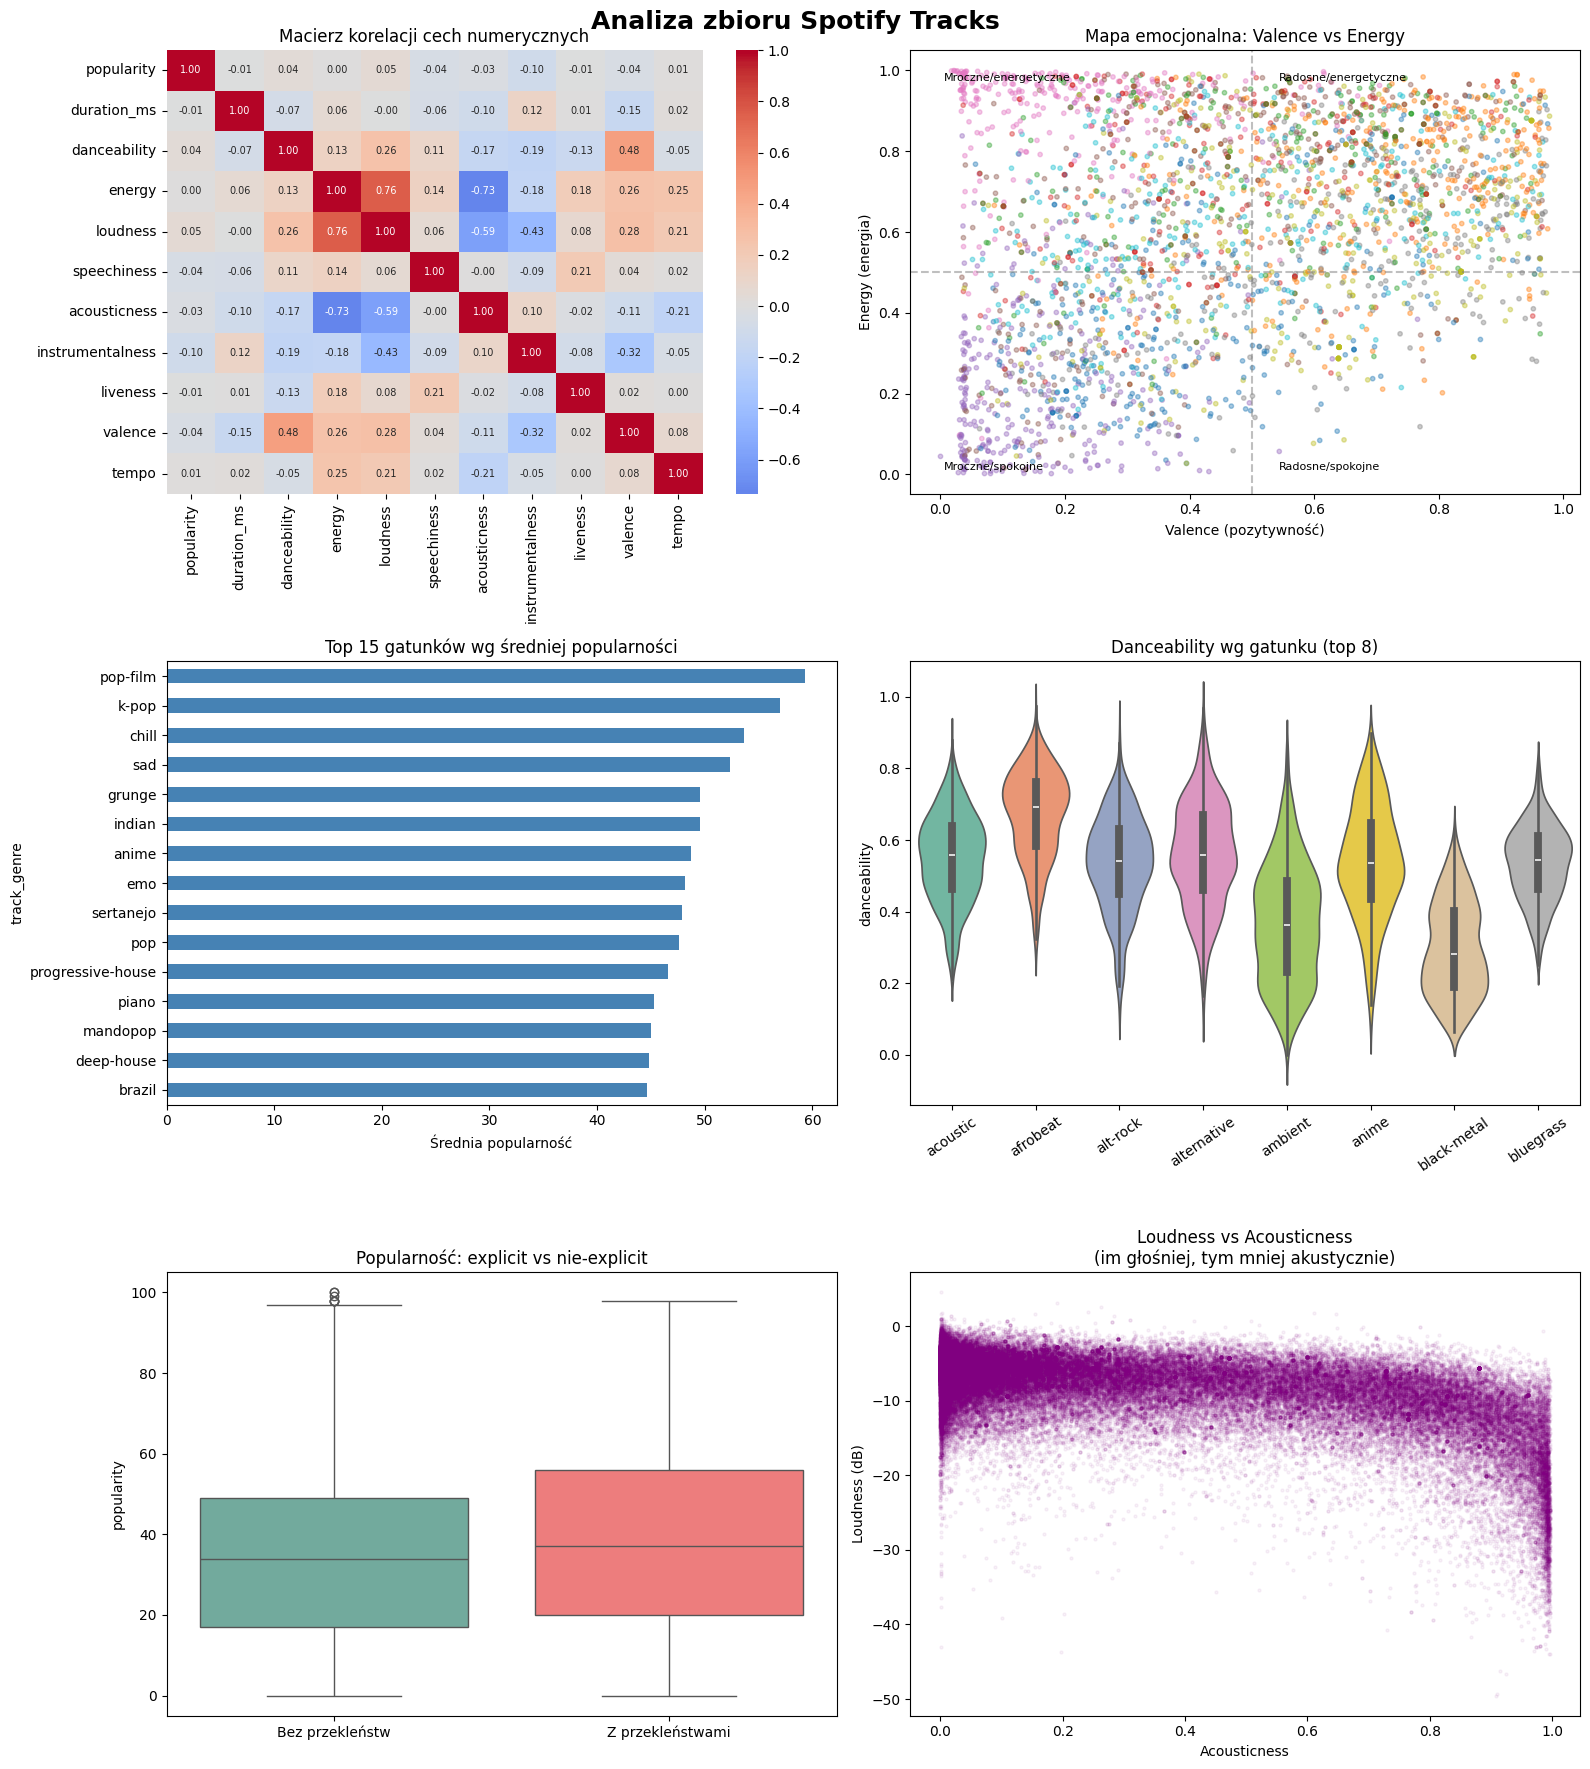

In [17]:
# MIEJSCE NA TWÓJ KOD
# sns.histplot(data=spotify, x='energy', hue='explicit', kde=True, bins=30)
top_genres = spotify_clean['track_genre'].value_counts().nlargest(10).index
spotify_top = spotify_clean[spotify_clean['track_genre'].isin(top_genres)]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Analiza zbioru Spotify Tracks', fontsize=18, fontweight='bold')

# 1. Heatmap korelacji
num_cols = ['popularity', 'duration_ms', 'danceability', 'energy',
            'loudness', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo']
corr = spotify_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0, 0], annot_kws={'size': 7})
axes[0, 0].set_title('Macierz korelacji cech numerycznych')

# 2. Valence vs Energy – mapa emocjonalna
sample = spotify_top.sample(3000, random_state=42)
axes[0, 1].scatter(sample['valence'], sample['energy'],
                   c=pd.Categorical(sample['track_genre']).codes,
                   cmap='tab10', alpha=0.4, s=10)
axes[0, 1].set_xlabel('Valence (pozytywność)')
axes[0, 1].set_ylabel('Energy (energia)')
axes[0, 1].set_title('Mapa emocjonalna: Valence vs Energy')
axes[0, 1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].text(0.05, 0.95, 'Mroczne/energetyczne', transform=axes[0,1].transAxes, fontsize=8, va='top')
axes[0, 1].text(0.55, 0.95, 'Radosne/energetyczne', transform=axes[0,1].transAxes, fontsize=8, va='top')
axes[0, 1].text(0.05, 0.05, 'Mroczne/spokojne',     transform=axes[0,1].transAxes, fontsize=8, va='bottom')
axes[0, 1].text(0.55, 0.05, 'Radosne/spokojne',     transform=axes[0,1].transAxes, fontsize=8, va='bottom')

# 3. Średnia popularność wg gatunku (top 15)
pop_by_genre = (spotify_clean.groupby('track_genre')['popularity']
                .mean().nlargest(15).sort_values())
pop_by_genre.plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Top 15 gatunków wg średniej popularności')
axes[1, 0].set_xlabel('Średnia popularność')

# 4. Rozkład energy wg gatunku (top 8)
spotify_top8 = spotify_clean[spotify_clean['track_genre'].isin(
    spotify_clean['track_genre'].value_counts().nlargest(8).index)]
sns.violinplot(data=spotify_top8, x='track_genre', y='danceability',
               ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Danceability wg gatunku (top 8)')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=35)

# 5. Explicit vs popularność
sns.boxplot(data=spotify_clean, x='explicit', y='popularity',
            ax=axes[2, 0], palette=['#69b3a2', '#ff6b6b'])
axes[2, 0].set_title('Popularność: explicit vs nie-explicit')
axes[2, 0].set_xticklabels(['Bez przekleństw', 'Z przekleństwami'])
axes[2, 0].set_xlabel('')

# 6. Rozkład loudness vs acousticness
axes[2, 1].scatter(spotify_clean['acousticness'], spotify_clean['loudness'],
                   alpha=0.05, s=5, color='purple')
axes[2, 1].set_xlabel('Acousticness')
axes[2, 1].set_ylabel('Loudness (dB)')
axes[2, 1].set_title('Loudness vs Acousticness\n(im głośniej, tym mniej akustycznie)')

plt.tight_layout()
plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [18]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [19]:
# MIEJSCE NA TWÓJ KOD
spotify['key_label']  = spotify['key'].map(key_map)
spotify['mode_label'] = spotify['mode'].map({1: 'Major', 0: 'Minor'})
spotify['emotion'] = spotify.apply(
    lambda row: emotion_map.get((row['key_label'], row['mode_label']), 'Unknown'),
    axis=1
)

print(spotify[['key', 'mode', 'key_label', 'mode_label', 'emotion']].head(10))
print("\nRozkład emocji:")
print(spotify['emotion'].value_counts())

   key  mode key_label mode_label      emotion
0    1     0        C#      Minor  Melancholic
1    1     1        C#      Major       Joyful
2    0     1         C      Major        Happy
3    0     1         C      Major        Happy
4    2     1         D      Major   Triumphant
5    6     1        F#      Major       Bright
6    2     1         D      Major   Triumphant
7   11     1         B      Major        Harsh
8    0     1         C      Major        Happy
9    1     1        C#      Major       Joyful

Rozkład emocji:
emotion
Happy          10197
Rustic         10149
Triumphant      9062
Joyful          7177
Pastoral        6860
Rich            5442
Passionate      5344
Lonely          5148
Grieving        4733
Tender          4453
Noisy           4275
Harsh           4134
Bright          4096
Tragic          4024
Gloomy          3825
Dark            3737
Magnificent     3719
Melancholic     3595
Serious         3096
Sad             2864
Pensive         2582
Cruel           2

## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [49]:
# MIEJSCE NA TWÓJ KOD
print("Wariancja time_signature:", spotify['time_signature'].var())
print("Unikalne wartości time_signature:", spotify['time_signature'].value_counts())

features_filter = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness',
                   'valence', 'tempo', 'duration_ms']

# spotify = spotify.drop(columns=["time_signature", "mode", "key", "popularity"])

print(f"\nPo filtrze: {len(features_filter)} cech (było 14 numerycznych)")
print("Usunięto: time_signature (mała wariancja), mode (0/1), key (niska korelacja z popularity), popularity")
print(spotify['key'].corr(spotify['popularity']))
print(spotify['key'].corr(spotify['popularity'], method='spearman'))

Wariancja time_signature: 0.1871607984253809
Unikalne wartości time_signature: time_signature
4    101843
3      9195
5      1826
1       973
0       163
Name: count, dtype: int64

Po filtrze: 10 cech (było 14 numerycznych)
Usunięto: time_signature (mała wariancja), mode (0/1), key (niska korelacja z popularity), popularity
-0.0038531547155607106
-0.0025902213790238867


### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [42]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ["duration_ms", "explicit", "danceability", "energy","key", "loudness", "mode", "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature"]

base_acc = classify(spotify, example_feats)


Features  : ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Test Acc  : 0.6214


### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [33]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [34]:
# przykładowe funkcje

def dataframe_xy(df):
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])

    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features_filter].values
    return X, y

# normalize to [0,1] range
def normalize(X):
    scaler = MinMaxScaler()
    return scaler.fit_transform(X)

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)

# remove outliers
def remove_outliers(X, y):
    clf = IsolationForest(contamination=0.05, random_state=42)
    mask = clf.fit_predict(X) == 1  # 1 = inlier, -1 = outlier
    return X[mask], y[mask]


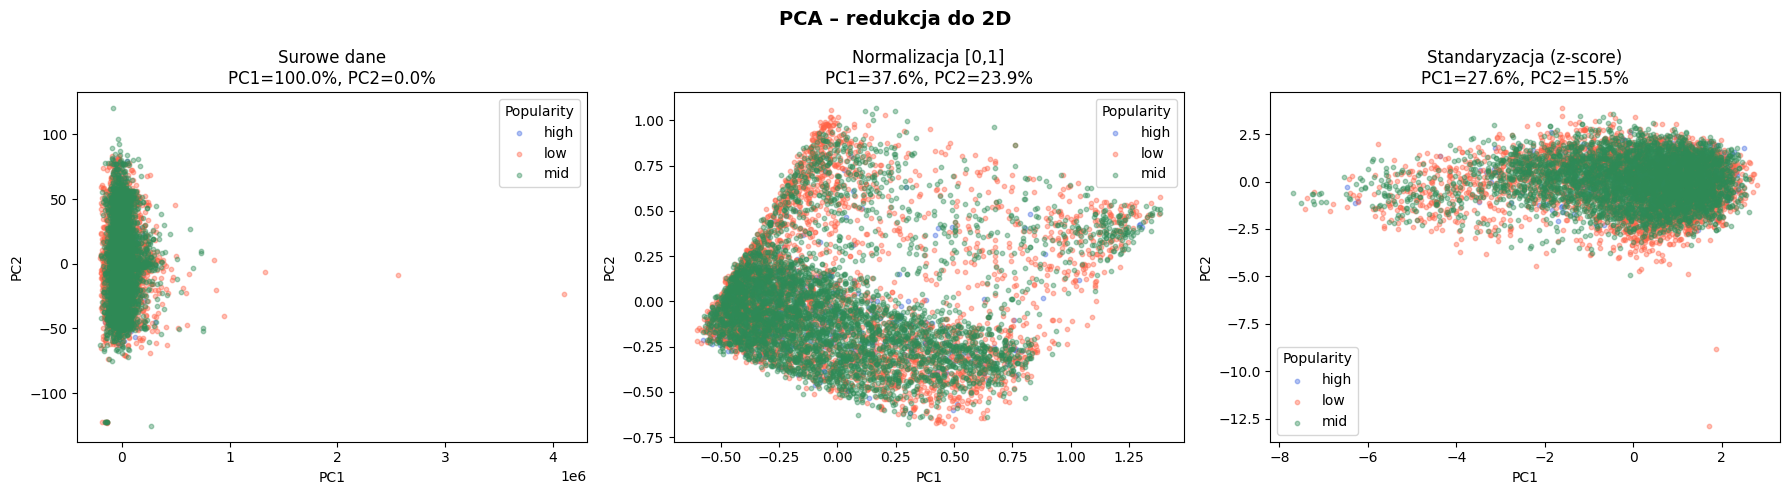

In [43]:
X, y = dataframe_xy(spotify)
X_raw = X
X_norm = normalize(X)
X_std = standarize(X)

label_names = {0: "high", 1: "low", 2: "mid"}  # LabelEncoder sortuje alfabetycznie
colors = {0: "royalblue", 1: "tomato", 2: "seagreen"}

datasets = {
    "Surowe dane": X_raw,
    "Normalizacja [0,1]": X_norm,
    "Standaryzacja (z-score)": X_std,
}

# 1. PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA – redukcja do 2D", fontsize=14, fontweight="bold")

for ax, (title, X_data) in zip(axes, datasets.items()):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_data)

    for label in np.unique(y):
        mask = y == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors[label], label=label_names[label],
                   alpha=0.4, s=10)

    var_explained = pca.explained_variance_ratio_
    ax.set_title(f"{title}\nPC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Popularity")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


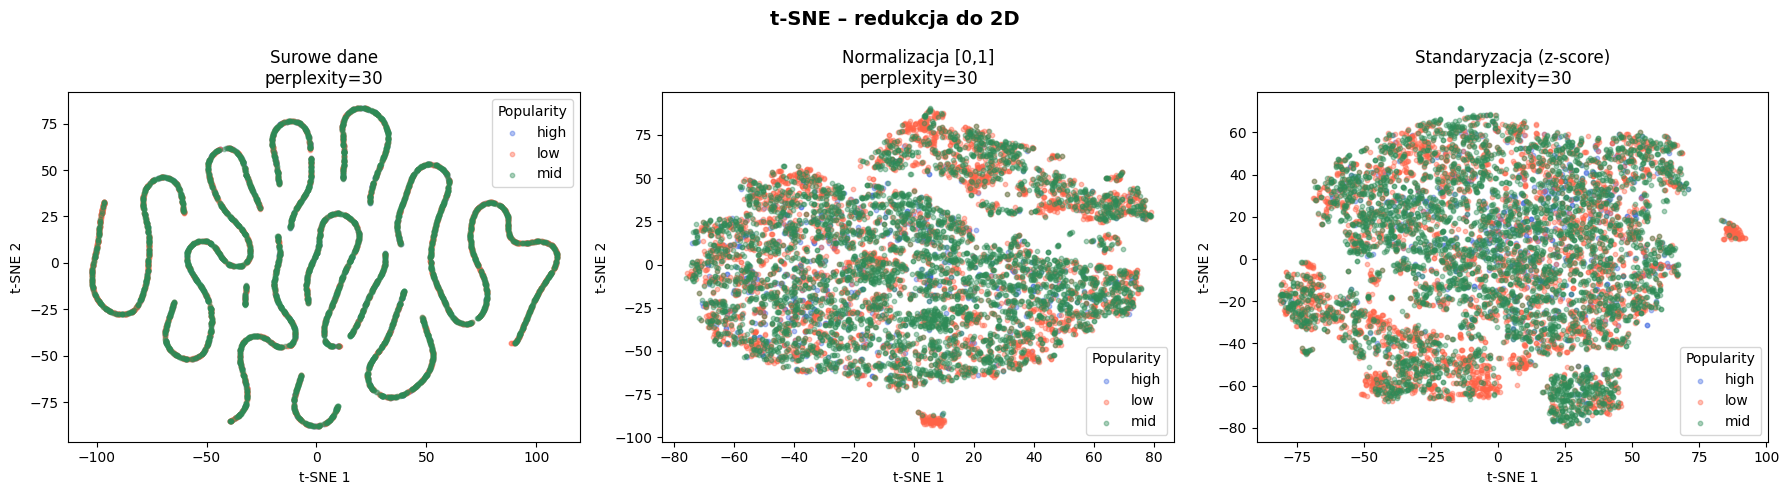

In [26]:
# 2. t-SNE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("t-SNE – redukcja do 2D", fontsize=14, fontweight="bold")

for ax, (title, X_data) in zip(axes, datasets.items()):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    X_2d = tsne.fit_transform(X_data)

    for label in np.unique(y):
        mask = y == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors[label], label=label_names[label],
                   alpha=0.4, s=10)

    ax.set_title(f"{title}\nperplexity=30")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(title="Popularity")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


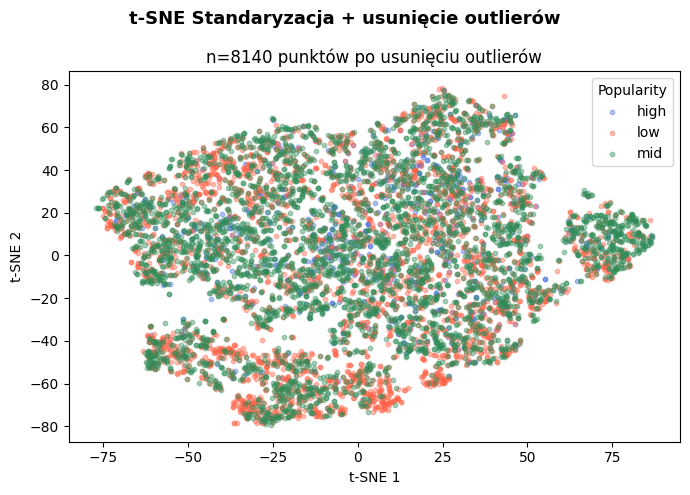

In [44]:
# 2b. t-SNE z usunięciem outlierów (tylko na standaryzowanych)
X_no_out, y_no_out = remove_outliers(X_std, y)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_2d = tsne.fit_transform(X_no_out)

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle("t-SNE Standaryzacja + usunięcie outlierów", fontsize=13, fontweight="bold")

for label in np.unique(y_no_out):
    mask = y_no_out == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[label], label=label_names[label],
               alpha=0.4, s=10)

ax.set_title(f"n={len(y_no_out)} punktów po usunięciu outlierów")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Popularity")
plt.tight_layout()
plt.show()

In [28]:
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([ 636, 3508, 4425]))